In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

os.makedirs(os.path.join('..', 'models'), exist_ok=True)
os.makedirs(os.path.join('..', 'outputs', 'plots'), exist_ok=True)


In [2]:
# Load data/processed/steam_cleaned.csv
data_path = os.path.join('..', 'data', 'processed', 'steam_cleaned.csv')
print(f"Loading cleaned data from {data_path}")
df = pd.read_csv(data_path)

# Drop nan reviews if any survived
df = df.dropna(subset=['cleaned_review', 'sentiment_label'])


Loading cleaned data from ..\data\processed\steam_cleaned.csv


In [3]:
# X = cleaned_review, y = sentiment_label
X = df['cleaned_review'].astype(str)
y = df['sentiment_label']

# Split: 80/20, stratified, random_state=42
print("Splitting dataset 80/20")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


Splitting dataset 80/20


In [4]:
# TF-IDF
print("Fitting TF-IDF Vectorizer...")
vectorizer = TfidfVectorizer(max_features=50000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Save TF-IDF
joblib.dump(vectorizer, os.path.join('..', 'models', 'sentiment_tfidf.pkl'))


Fitting TF-IDF Vectorizer...


['..\\models\\sentiment_tfidf.pkl']

In [5]:
# Model A — Logistic Regression
print("Training Logistic Regression Model...")
lr_model = LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_lr = lr_model.predict(X_test_tfidf)
y_prob_lr = lr_model.predict_proba(X_test_tfidf)[:, 1]

print("### Logistic Regression Metrics ###")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_lr):.4f}")

# Save
joblib.dump(lr_model, os.path.join('..', 'models', 'sentiment_lr.pkl'))


Training Logistic Regression Model...


### Logistic Regression Metrics ###
Accuracy: 0.7595
F1-Score: 0.8354
ROC-AUC:  0.8836


['..\\models\\sentiment_lr.pkl']

In [6]:
# Model B — XGBoost
print("Training XGBoost Classifier...")
xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss')

xgb_model.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_xgb = xgb_model.predict(X_test_tfidf)
y_prob_xgb = xgb_model.predict_proba(X_test_tfidf)[:, 1]

print("\n### XGBoost Metrics ###")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_xgb):.4f}")

# Save
joblib.dump(xgb_model, os.path.join('..', 'models', 'sentiment_xgb.pkl'))


Training XGBoost Classifier...



### XGBoost Metrics ###
Accuracy: 0.8589
F1-Score: 0.9199
ROC-AUC:  0.8429


['..\\models\\sentiment_xgb.pkl']

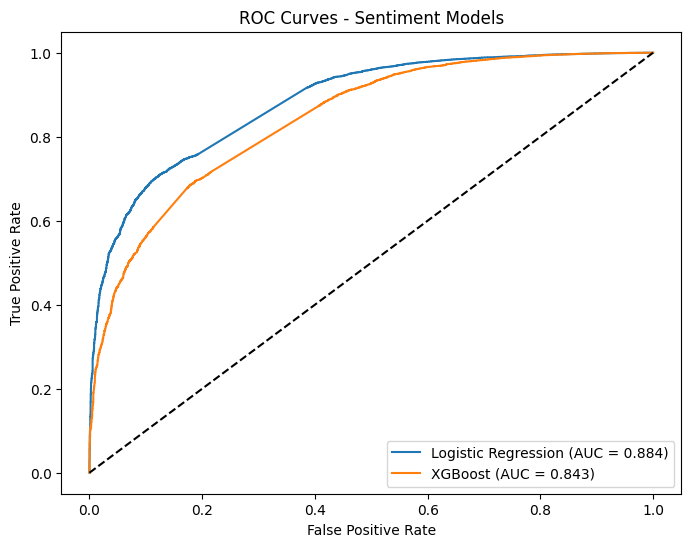

In [7]:
# Plot: ROC curves for both models on same axes
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves - Sentiment Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.savefig(os.path.join('..', 'outputs', 'plots', '08_sentiment_roc_curves.png'))
plt.show()


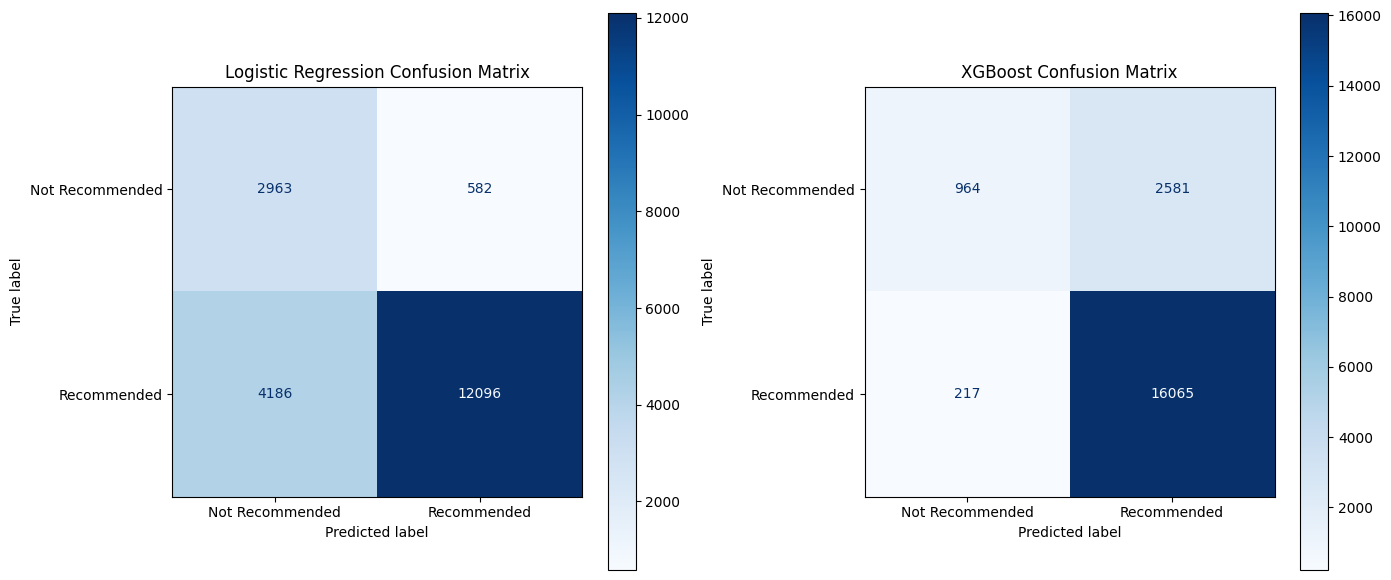

In [8]:
# Plot: Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Not Recommended', 'Recommended'])
disp_lr.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Logistic Regression Confusion Matrix')

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Not Recommended', 'Recommended'])
disp_xgb.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title('XGBoost Confusion Matrix')

plt.tight_layout()
plt.savefig(os.path.join('..', 'outputs', 'plots', '09_sentiment_confusion_matrices.png'))
plt.show()


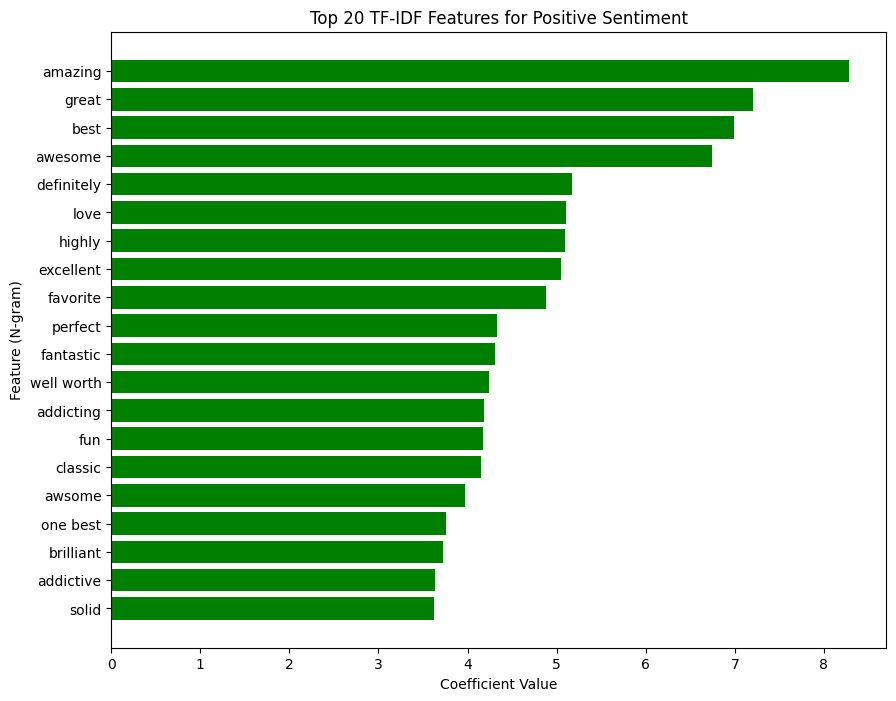

In [9]:
# Plot: Top 20 TF-IDF feature weights for positive class
feature_names = vectorizer.get_feature_names_out()
coefs = lr_model.coef_[0]

# Get indices of top 20 positive coefficients
top20_idx = np.argsort(coefs)[-20:]

top20_features = [feature_names[i] for i in top20_idx]
top20_coefs = [coefs[i] for i in top20_idx]

plt.figure(figsize=(10, 8))
plt.barh(top20_features, top20_coefs, color='green')
plt.title('Top 20 TF-IDF Features for Positive Sentiment')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature (N-gram)')
plt.savefig(os.path.join('..', 'outputs', 'plots', '10_sentiment_top_features.png'))
plt.show()
